# Importing dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import glob

from warnings import filterwarnings
filterwarnings('ignore')

# Data Audit

In [2]:
DATA_PATH = r'P:\Python\IITR\Fundamentals of Ai Project\data\*.csv'

try:
    all_files = glob.glob(DATA_PATH)
    if not all_files:
        print("No Files Imported")
    else:
        df_list = [pd.read_csv(file) for file in all_files]
        print("All Files are Imported Successfully ")
except Exception as e:
    print(f"An error occurred: {e}")

All Files are Imported Successfully 


In [3]:
recommandation = df_list[0]
crop_yield = df_list[1]
price = df_list[2]


# Analysis of the Recommendation data 

In [4]:
recommandation.info()



<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [5]:
recommandation.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,label
1648,13,16,8,34.740049,93.123170,6.949839,100.196785,orange
1807,34,6,27,25.847263,90.926695,5.860740,147.888899,coconut
2134,86,31,35,27.012073,60.766453,6.485761,191.450893,coffee
1945,110,39,25,22.606121,77.342640,7.208795,75.136172,cotton
506,14,55,15,27.335809,55.277559,8.050304,73.447753,mothbeans


In [6]:

recommandation['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [7]:
RECOMMANDATION_TARGET = 'label'
# Evenly distributed 


- Later we have to been Perfroming OHE on target column

In [8]:
recommandation.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [9]:
recommandation.corr(numeric_only=True)

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


<Axes: >

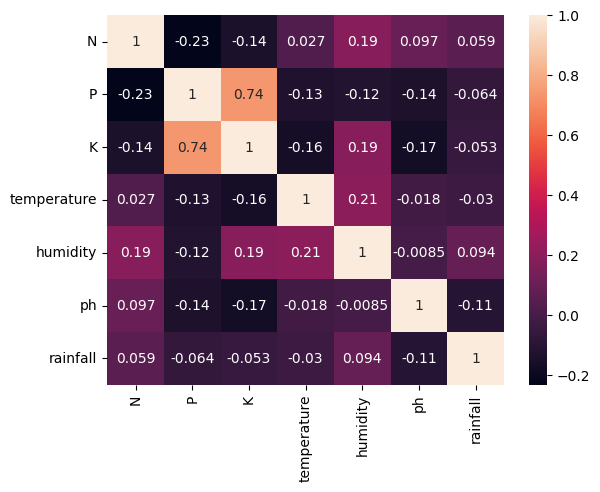

In [10]:
sns.heatmap(recommandation.corr(numeric_only=True), annot=True)

- Little to No ccorrelatein in the Features itself but there are a good about of linearlty in the K and P persent in the soil we have to think about that 

## Data Cleaning

In [11]:
recommandation.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

- No Cell ahveinng the missing data

In [12]:
recommandation.duplicated().sum()

np.int64(0)

- No duplicaed cell found

##### N and its frequenct

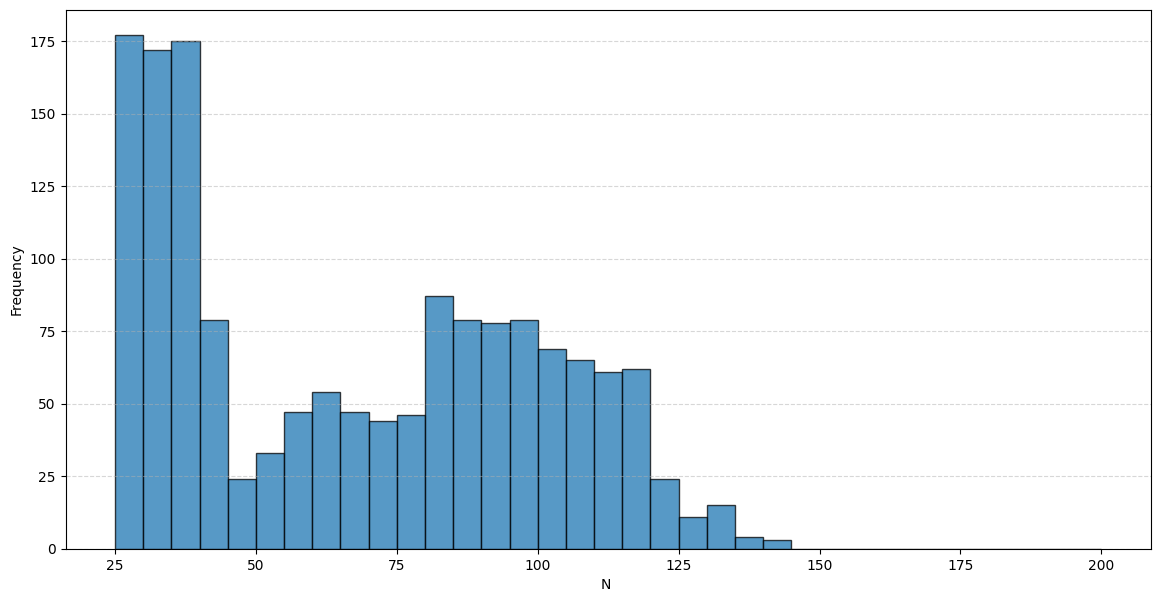

In [ ]:

plt.figure(figsize=(14,7))
bins = list(np.arange(25,201,5))
plt.hist(recommandation['N'], bins=bins, edgecolor = 'black', alpha = np.float64(0.75))
plt.xlabel('N ')
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.5)

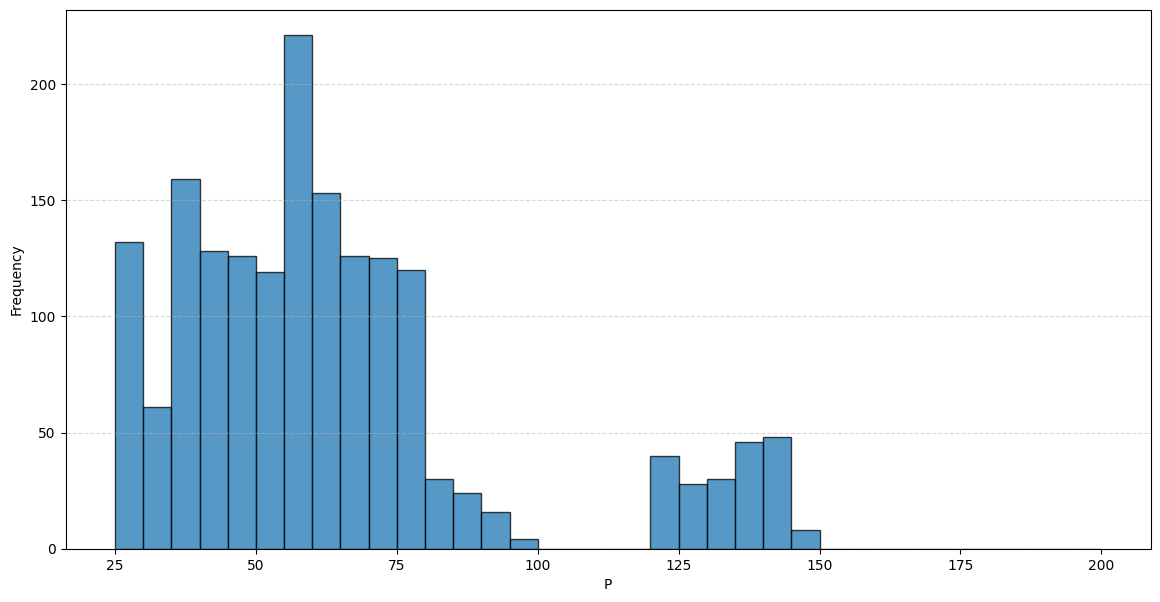

In [14]:
plt.figure(figsize=(14,7))
bins = list(np.arange(25,201,5))
plt.hist(recommandation['P'], bins=bins, edgecolor = 'black', alpha = np.float64(0.75))
plt.xlabel('P')
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.5)

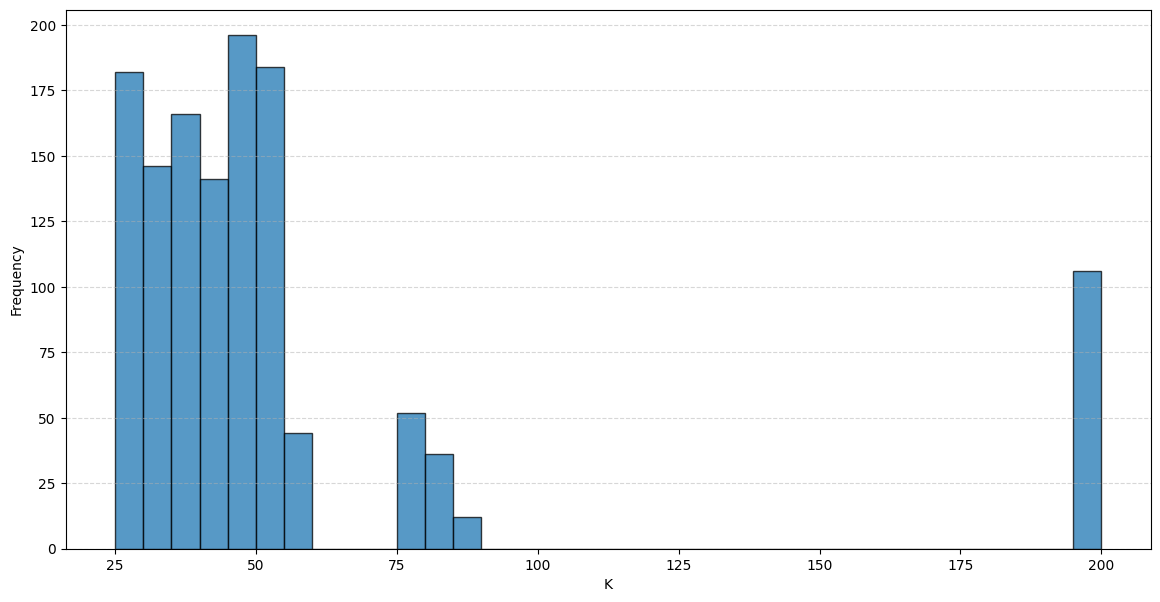

In [15]:
plt.figure(figsize=(14,7))
bins = list(np.arange(25,201,5))
plt.hist(recommandation['K'], bins=bins, edgecolor = 'black', alpha = np.float64(0.75))
plt.xlabel('K')
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.5)

## Dataset Sources

For this project, three publicly available agricultural datasets were selected from Kaggle to develop and evaluate different classical machine learning models for agricultural decision-making.

### 1. Crop Recommendation Dataset

**Source:** Kaggle — Siddharth S.
**Link:** https://www.kaggle.com/datasets/siddharthss/crop-recommendation-dataset

This dataset contains agricultural and environmental parameters such as **Nitrogen (N), Phosphorus (P), Potassium (K), temperature, humidity, soil pH, rainfall, and crop label**. It is used for the **crop recommendation** component of the project, where a classification model predicts the most suitable crop based on soil and climatic conditions.

### 2. Crop Production Statistics — India

**Source:** Kaggle — Nikhil Mahajan
**Link:** https://www.kaggle.com/datasets/nikhilmahajan29/crop-production-statistics-india

This dataset contains historical **crop production statistics from India**, including information related to crops, states/regions, years, area cultivated, and production. It is used for the **crop yield/production analysis and prediction** component of the project.

### 3. Price of Agricultural Commodities Data

**Source:** Kaggle — Arvind Khoda
**Link:** https://www.kaggle.com/code/arvindkhoda/price-of-agricultural-commodities-data/input

This dataset contains historical **agricultural commodity market-price information**. It is used to study agricultural price patterns and develop a **commodity price prediction** model using classical machine learning techniques.

### Overall Use of the Datasets

The three datasets allow the project to address different agricultural decision-making problems:

| Dataset                       | Task                                     | ML Problem     |
| ----------------------------- | ---------------------------------------- | -------------- |
| Crop Recommendation           | Recommend a suitable crop                | Classification |
| Crop Production Statistics    | Predict/analyse crop yield or production | Regression     |
| Agricultural Commodity Prices | Predict commodity prices                 | Regression     |

Together, these datasets provide the foundation for developing a multi-model **classical machine learning based agricultural decision-support system**.
